# Classification 


In [179]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

In [180]:
from pathlib import Path

# Works whether the notebook runs from project root or notebooks/
candidate_roots = [Path.cwd(), Path.cwd().parent]
project_root = next(
    (p for p in candidate_roots if (p / "data" / "processed").exists()),
    Path.cwd()
 )
processed_dir = project_root / "data" / "processed"

news_df = pd.read_csv(processed_dir / "news_preprocessed.csv")
emails_df = pd.read_csv(processed_dir / "emails_preprocessed.csv")
contracts_df = pd.read_csv(processed_dir / "contracts_preprocessed.csv")
invoices_df = pd.read_csv(processed_dir / "invoices_preprocessed.csv")

full_df = pd.read_csv(processed_dir / "full_dataset_preprocessed.csv")

class imbalance

In [181]:
class_counts = full_df["doc_type"].value_counts()
class_counts

doc_type
email       15495
news         2123
invoice       564
contract      494
Name: count, dtype: int64

In [182]:
(class_counts / len(full_df) * 100).round(2)

doc_type
email       82.97
news        11.37
invoice      3.02
contract     2.65
Name: count, dtype: float64

We need to decide the dataset for training. for the baseline use full dataset and later compare with downsampled emails and class weighted models

In [183]:
full_df["is_synthetic"] = full_df["is_synthetic"].fillna(False).astype(bool)

real_df  = full_df[~full_df["is_synthetic"]].copy()
synth_df = full_df[ full_df["is_synthetic"]].copy()

print(f"Real documents:      {len(real_df)}")
print(f"Synthetic documents: {len(synth_df)}  (will be added to training set only)")
print(f"Real class distribution:\n{real_df['doc_type'].value_counts().to_string()}")

Real documents:      18176
Synthetic documents: 500  (will be added to training set only)
Real class distribution:
doc_type
email       15495
news         2123
contract      494
invoice        64


In [184]:
import sys
sys.path.insert(0, str(project_root))
from src.preprocessing import clean_for_classifier

# Clean real data — this is what gets split into train / val / test
X_real = real_df["text"].apply(clean_for_classifier)
y_real = real_df["doc_type"]

# Clean synthetic data — will be appended to the training set ONLY
X_synth = synth_df["text"].apply(clean_for_classifier)
y_synth = synth_df["doc_type"]

print(f"Real samples:      {len(X_real)}")
print(f"Synthetic samples: {len(X_synth)}")
print(f"Sample cleaned invoice text:\n{X_real[y_real == 'invoice'].iloc[0][:300]}")

Real samples:      18176
Synthetic samples: 500
Sample cleaned invoice text:
__inv_number__ __inv_header__ __bill_to__ __amount_due__ __due_date__ cream and white simple minimalist catering services invoice invoice borcelle | catering services description qty total total $1000 issued to: amount due $550 invoice no: #612345 unit price bank details grilled chicken 2 $200 brusc


In [185]:
# Synthetic augmentation removed — real English invoice data is now merged
# in 03_preprocessing.ipynb from data/raw/invoices/converted_invoice_dataset.csv
# so invoices_preprocessed.csv already contains both SROIE + English invoices.


## split

In [186]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_real, y_real,
    test_size=0.30,
    random_state=42,
    stratify=y_real
)

In [187]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [188]:
# Append synthetic invoices to training set ONLY.
# Val and test remain 100 % real data so reported metrics are unbiased.
n_train_before = len(X_train)
X_train = pd.concat([X_train, X_synth], ignore_index=True)
y_train = pd.concat([y_train, y_synth], ignore_index=True)

print(f"Training set: {n_train_before} real + {len(X_synth)} synthetic = {len(X_train)} total")
print(f"Validation:   {len(X_val)}  (real only)")
print(f"Test:         {len(X_test)}  (real only)")

Training set: 12723 real + 500 synthetic = 13223 total
Validation:   2726  (real only)
Test:         2727  (real only)


In [189]:
print("Train (real + synthetic):", X_train.shape[0])
print("Validation (real only): ", X_val.shape[0])
print("Test (real only):       ", X_test.shape[0])

Train (real + synthetic): 13223
Validation (real only):  2726
Test (real only):        2727


In [190]:
print("\nTrain distribution:")
print(y_train.value_counts())

print("\nValidation distribution:")
print(y_val.value_counts())

print("\nTest distribution:")
print(y_test.value_counts())


Train distribution:
doc_type
email       10846
news         1486
invoice       545
contract      346
Name: count, dtype: int64

Validation distribution:
doc_type
email       2324
news         318
contract      74
invoice       10
Name: count, dtype: int64

Test distribution:
doc_type
email       2325
news         319
contract      74
invoice        9
Name: count, dtype: int64


## Vectorize text with tf-idf

In [191]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=3,
    max_features=20000
)

In [192]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

In [193]:
# Duplicate TF-IDF fit removed — vectorizer is fitted once in the cell above.


In [194]:
print("X_train_tfidf:", X_train_tfidf.shape)
print("X_val_tfidf:", X_val_tfidf.shape)
print("X_test_tfidf:", X_test_tfidf.shape)

X_train_tfidf: (13223, 20000)
X_val_tfidf: (2726, 20000)
X_test_tfidf: (2727, 20000)


## Multinomial Naive Bayes

In [195]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_val_pred_nb = nb_model.predict(X_val_tfidf)
y_test_pred_nb = nb_model.predict(X_test_tfidf)

In [196]:
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred_nb))
print("Validation Macro F1:", f1_score(y_val, y_val_pred_nb, average="macro"))
print("Validation Weighted F1:", f1_score(y_val, y_val_pred_nb, average="weighted"))

Validation Accuracy: 0.9955979457079971
Validation Macro F1: 0.9831670876321761
Validation Weighted F1: 0.9955205707359189


In [197]:
print(classification_report(y_val, y_val_pred_nb))

              precision    recall  f1-score   support

    contract       1.00      0.89      0.94        74
       email       1.00      1.00      1.00      2324
     invoice       1.00      1.00      1.00        10
        news       0.99      1.00      0.99       318

    accuracy                           1.00      2726
   macro avg       1.00      0.97      0.98      2726
weighted avg       1.00      1.00      1.00      2726



In [198]:
val_cm_nb = pd.DataFrame(
    confusion_matrix(y_val, y_val_pred_nb, labels=nb_model.classes_),
    index=nb_model.classes_,
    columns=nb_model.classes_
)
val_cm_nb

,contract,email,invoice,news
contract,66,7,0,1
email,0,2321,0,3
invoice,0,0,10,0
news,0,1,0,317


In [199]:
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_nb))
print("Test Macro F1:", f1_score(y_test, y_test_pred_nb, average="macro"))
print("Test Weighted F1:", f1_score(y_test, y_test_pred_nb, average="weighted"))

Test Accuracy: 0.9944994499449945
Test Macro F1: 0.982178591117866
Test Weighted F1: 0.9944245929888433


In [200]:
print(classification_report(y_test, y_test_pred_nb))

              precision    recall  f1-score   support

    contract       1.00      0.89      0.94        74
       email       1.00      1.00      1.00      2325
     invoice       1.00      1.00      1.00         9
        news       0.98      0.99      0.99       319

    accuracy                           0.99      2727
   macro avg       1.00      0.97      0.98      2727
weighted avg       0.99      0.99      0.99      2727



In [201]:
test_cm_nb = pd.DataFrame(
    confusion_matrix(y_test, y_test_pred_nb, labels=nb_model.classes_),
    index=nb_model.classes_,
    columns=nb_model.classes_
)
test_cm_nb

,contract,email,invoice,news
contract,66,8,0,0
email,0,2320,0,5
invoice,0,0,9,0
news,0,2,0,317


In [202]:
nb_results = pd.DataFrame({
    "model": ["Multinomial Naive Bayes"],
    "val_accuracy": [accuracy_score(y_val, y_val_pred_nb)],
    "val_macro_f1": [f1_score(y_val, y_val_pred_nb, average="macro")],
    "val_weighted_f1": [f1_score(y_val, y_val_pred_nb, average="weighted")],
    "test_accuracy": [accuracy_score(y_test, y_test_pred_nb)],
    "test_macro_f1": [f1_score(y_test, y_test_pred_nb, average="macro")],
    "test_weighted_f1": [f1_score(y_test, y_test_pred_nb, average="weighted")]
})
nb_results

,model,val_accuracy,val_macro_f1,val_weighted_f1,test_accuracy,test_macro_f1,test_weighted_f1
0,Multinomial Naive Bayes,0.995598,0.983167,0.995521,0.994499,0.982179,0.994425


## Linear SVM

In [203]:
svm_model = LinearSVC(random_state=42, class_weight='balanced')
svm_model.fit(X_train_tfidf, y_train)


,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseud

In [204]:
y_val_pred_svm = svm_model.predict(X_val_tfidf)
y_test_pred_svm = svm_model.predict(X_test_tfidf)

In [205]:
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred_svm))
print("Validation Macro F1:", f1_score(y_val, y_val_pred_svm, average="macro"))
print("Validation Weighted F1:", f1_score(y_val, y_val_pred_svm, average="weighted"))

Validation Accuracy: 0.9988994864269992
Validation Macro F1: 0.9970179913501055
Validation Weighted F1: 0.998900664128814


In [206]:
print(classification_report(y_val, y_val_pred_svm))

              precision    recall  f1-score   support

    contract       1.00      0.99      0.99        74
       email       1.00      1.00      1.00      2324
     invoice       1.00      1.00      1.00        10
        news       0.99      1.00      1.00       318

    accuracy                           1.00      2726
   macro avg       1.00      1.00      1.00      2726
weighted avg       1.00      1.00      1.00      2726



In [207]:
val_cm_svm = pd.DataFrame(
    confusion_matrix(y_val, y_val_pred_svm, labels=svm_model.classes_),
    index=svm_model.classes_,
    columns=svm_model.classes_
)
val_cm_svm

,contract,email,invoice,news
contract,73,0,0,1
email,0,2322,0,2
invoice,0,0,10,0
news,0,0,0,318


In [208]:
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_svm))
print("Test Macro F1:", f1_score(y_test, y_test_pred_svm, average="macro"))
print("Test Weighted F1:", f1_score(y_test, y_test_pred_svm, average="weighted"))

Test Accuracy: 0.9988998899889989
Test Macro F1: 0.9960679012994951
Test Weighted F1: 0.99889972041875


In [209]:
print(classification_report(y_test, y_test_pred_svm))

              precision    recall  f1-score   support

    contract       0.99      0.99      0.99        74
       email       1.00      1.00      1.00      2325
     invoice       1.00      1.00      1.00         9
        news       1.00      1.00      1.00       319

    accuracy                           1.00      2727
   macro avg       1.00      1.00      1.00      2727
weighted avg       1.00      1.00      1.00      2727



In [210]:
test_cm_svm = pd.DataFrame(
    confusion_matrix(y_test, y_test_pred_svm, labels=svm_model.classes_),
    index=svm_model.classes_,
    columns=svm_model.classes_
)
test_cm_svm

,contract,email,invoice,news
contract,73,1,0,0
email,1,2324,0,0
invoice,0,0,9,0
news,0,1,0,318


In [211]:
svm_results = pd.DataFrame({
    "model": ["Linear SVM (balanced)"],
    "val_accuracy": [accuracy_score(y_val, y_val_pred_svm)],
    "val_macro_f1": [f1_score(y_val, y_val_pred_svm, average="macro")],
    "val_weighted_f1": [f1_score(y_val, y_val_pred_svm, average="weighted")],
    "test_accuracy": [accuracy_score(y_test, y_test_pred_svm)],
    "test_macro_f1": [f1_score(y_test, y_test_pred_svm, average="macro")],
    "test_weighted_f1": [f1_score(y_test, y_test_pred_svm, average="weighted")]
})

pd.concat([nb_results, svm_results], ignore_index=True)

,model,val_accuracy,val_macro_f1,val_weighted_f1,test_accuracy,test_macro_f1,test_weighted_f1
0,Multinomial Naive Bayes,0.995598,0.983167,0.995521,0.994499,0.982179,0.994425
1,Linear SVM (balanced),0.998899,0.997018,0.998901,0.998900,0.996068,0.998900


## Logistic regression

In [212]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',   # compensates for email-heavy imbalance
)

lr_model.fit(X_train_tfidf, y_train)

/Users/denis/Desktop/stats-final-project/Document-Classification-and-Information-Extraction-/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [213]:
y_val_pred_lr = lr_model.predict(X_val_tfidf)
y_test_pred_lr = lr_model.predict(X_test_tfidf)

In [214]:
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred_lr))
print("Validation Macro F1:", f1_score(y_val, y_val_pred_lr, average="macro"))
print("Validation Weighted F1:", f1_score(y_val, y_val_pred_lr, average="weighted"))

Validation Accuracy: 0.9977989728539985
Validation Macro F1: 0.9944023211330395
Validation Weighted F1: 0.9978051388683699


In [215]:
print(classification_report(y_val, y_val_pred_lr))

              precision    recall  f1-score   support

    contract       0.99      0.99      0.99        74
       email       1.00      1.00      1.00      2324
     invoice       1.00      1.00      1.00        10
        news       0.98      1.00      0.99       318

    accuracy                           1.00      2726
   macro avg       0.99      1.00      0.99      2726
weighted avg       1.00      1.00      1.00      2726



In [216]:
val_cm_lr = pd.DataFrame(
    confusion_matrix(y_val, y_val_pred_lr, labels=lr_model.classes_),
    index=lr_model.classes_,
    columns=lr_model.classes_
)
val_cm_lr

,contract,email,invoice,news
contract,73,0,0,1
email,1,2319,0,4
invoice,0,0,10,0
news,0,0,0,318


In [217]:
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_lr))
print("Test Macro F1:", f1_score(y_test, y_test_pred_lr, average="macro"))
print("Test Weighted F1:", f1_score(y_test, y_test_pred_lr, average="weighted"))

Test Accuracy: 0.9966996699669967
Test Macro F1: 0.9921456025357289
Test Weighted F1: 0.9967084395983453


In [218]:
print(classification_report(y_test, y_test_pred_lr))

              precision    recall  f1-score   support

    contract       0.97      0.99      0.98        74
       email       1.00      1.00      1.00      2325
     invoice       1.00      1.00      1.00         9
        news       0.98      1.00      0.99       319

    accuracy                           1.00      2727
   macro avg       0.99      1.00      0.99      2727
weighted avg       1.00      1.00      1.00      2727



In [219]:
test_cm_lr = pd.DataFrame(
    confusion_matrix(y_test, y_test_pred_lr, labels=lr_model.classes_),
    index=lr_model.classes_,
    columns=lr_model.classes_
)
test_cm_lr

,contract,email,invoice,news
contract,73,1,0,0
email,2,2318,0,5
invoice,0,0,9,0
news,0,1,0,318


In [220]:
lr_results = pd.DataFrame({
    'model': ['Logistic Regression'],
    'val_accuracy':    [accuracy_score(y_val, y_val_pred_lr)],
    'val_macro_f1':    [f1_score(y_val, y_val_pred_lr, average='macro')],
    'val_weighted_f1': [f1_score(y_val, y_val_pred_lr, average='weighted')],
    'test_accuracy':   [accuracy_score(y_test, y_test_pred_lr)],
    'test_macro_f1':   [f1_score(y_test, y_test_pred_lr, average='macro')],
    'test_weighted_f1':[f1_score(y_test, y_test_pred_lr, average='weighted')],
})
lr_results


,model,val_accuracy,val_macro_f1,val_weighted_f1,test_accuracy,test_macro_f1,test_weighted_f1
0,Logistic Regression,0.997799,0.994402,0.997805,0.9967,0.992146,0.996708


## Random Forest

Random Forest serves as the tree-based ensemble baseline. Note that RF on high-dimensional
sparse TF-IDF is typically slower and slightly weaker than linear models for text, but
it provides a useful non-linear comparison point.


In [221]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1,
)
rf_model.fit(X_train_tfidf, y_train)

y_val_pred_rf  = rf_model.predict(X_val_tfidf)
y_test_pred_rf = rf_model.predict(X_test_tfidf)


In [222]:
print('Validation Accuracy:', accuracy_score(y_val, y_val_pred_rf))
print('Validation Macro F1:', f1_score(y_val, y_val_pred_rf, average='macro'))
print('Validation Weighted F1:', f1_score(y_val, y_val_pred_rf, average='weighted'))


Validation Accuracy: 0.995964783565664
Validation Macro F1: 0.9893540570127742
Validation Weighted F1: 0.9959382681782979


In [223]:
print(classification_report(y_val, y_val_pred_rf))


              precision    recall  f1-score   support

    contract       1.00      0.95      0.97        74
       email       1.00      1.00      1.00      2324
     invoice       1.00      1.00      1.00        10
        news       0.99      0.98      0.99       318

    accuracy                           1.00      2726
   macro avg       1.00      0.98      0.99      2726
weighted avg       1.00      1.00      1.00      2726



In [224]:
val_cm_rf = pd.DataFrame(
    confusion_matrix(y_val, y_val_pred_rf, labels=rf_model.classes_),
    index=rf_model.classes_, columns=rf_model.classes_
)
val_cm_rf


,contract,email,invoice,news
contract,70,3,0,1
email,0,2323,0,1
invoice,0,0,10,0
news,0,6,0,312


In [225]:
print('Test Accuracy:', accuracy_score(y_test, y_test_pred_rf))
print('Test Macro F1:', f1_score(y_test, y_test_pred_rf, average='macro'))
print('Test Weighted F1:', f1_score(y_test, y_test_pred_rf, average='weighted'))


Test Accuracy: 0.9977997799779978
Test Macro F1: 0.9946758904510538
Test Weighted F1: 0.9977915471407094


In [226]:
print(classification_report(y_test, y_test_pred_rf))


              precision    recall  f1-score   support

    contract       1.00      0.97      0.99        74
       email       1.00      1.00      1.00      2325
     invoice       1.00      1.00      1.00         9
        news       1.00      0.99      0.99       319

    accuracy                           1.00      2727
   macro avg       1.00      0.99      0.99      2727
weighted avg       1.00      1.00      1.00      2727



In [227]:
test_cm_rf = pd.DataFrame(
    confusion_matrix(y_test, y_test_pred_rf, labels=rf_model.classes_),
    index=rf_model.classes_, columns=rf_model.classes_
)
test_cm_rf


,contract,email,invoice,news
contract,72,2,0,0
email,0,2325,0,0
invoice,0,0,9,0
news,0,4,0,315


In [228]:
rf_results = pd.DataFrame({
    'model': ['Random Forest'],
    'val_accuracy':    [accuracy_score(y_val, y_val_pred_rf)],
    'val_macro_f1':    [f1_score(y_val, y_val_pred_rf, average='macro')],
    'val_weighted_f1': [f1_score(y_val, y_val_pred_rf, average='weighted')],
    'test_accuracy':   [accuracy_score(y_test, y_test_pred_rf)],
    'test_macro_f1':   [f1_score(y_test, y_test_pred_rf, average='macro')],
    'test_weighted_f1':[f1_score(y_test, y_test_pred_rf, average='weighted')],
})
rf_results


,model,val_accuracy,val_macro_f1,val_weighted_f1,test_accuracy,test_macro_f1,test_weighted_f1
0,Random Forest,0.995965,0.989354,0.995938,0.9978,0.994676,0.997792


## XGBoost on TF-IDF

Gradient-boosted trees on the same sparse TF-IDF matrix used by the linear models. XGBoost often beats SVM on short-to-medium documents and provides a non-linear ensemble baseline. `use_label_encoder=False` avoids a deprecation warning; `eval_metric='mlogloss'` is appropriate for multiclass.

In [229]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost requires integer labels
_le = LabelEncoder()
y_train_enc  = _le.fit_transform(y_train)
y_val_enc    = _le.transform(y_val)
y_test_enc   = _le.transform(y_test)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
)
xgb_model.fit(
    X_train_tfidf, y_train_enc,
    eval_set=[(X_val_tfidf, y_val_enc)],
    verbose=False,
)

y_val_pred_xgb_enc  = xgb_model.predict(X_val_tfidf)
y_test_pred_xgb_enc = xgb_model.predict(X_test_tfidf)

# Decode back to string labels for sklearn metrics
y_val_pred_xgb  = _le.inverse_transform(y_val_pred_xgb_enc)
y_test_pred_xgb = _le.inverse_transform(y_test_pred_xgb_enc)

print('=== XGBoost — Validation ===')
print('Accuracy :', round(accuracy_score(y_val, y_val_pred_xgb), 4))
print('Macro F1 :', round(f1_score(y_val, y_val_pred_xgb, average='macro'), 4))
print(classification_report(y_val, y_val_pred_xgb))

print('=== XGBoost — Test ===')
print('Accuracy :', round(accuracy_score(y_test, y_test_pred_xgb), 4))
print('Macro F1 :', round(f1_score(y_test, y_test_pred_xgb, average='macro'), 4))
print(classification_report(y_test, y_test_pred_xgb))


/Users/denis/Desktop/stats-final-project/Document-Classification-and-Information-Extraction-/.venv/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [20:18:06] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== XGBoost — Validation ===
Accuracy : 0.993
Macro F1 : 0.9858
              precision    recall  f1-score   support

    contract       1.00      0.95      0.97        74
       email       0.99      1.00      1.00      2324
     invoice       1.00      1.00      1.00        10
        news       0.98      0.97      0.97       318

    accuracy                           0.99      2726
   macro avg       0.99      0.98      0.99      2726
weighted avg       0.99      0.99      0.99      2726

=== XGBoost — Test ===
Accuracy : 0.9952
Macro F1 : 0.9915
              precision    recall  f1-score   support

    contract       1.00      0.97      0.99        74
       email       1.00      1.00      1.00      2325
     invoice       1.00      1.00      1.00         9
        news       0.99      0.98      0.98       319

    accuracy                           1.00      2727
   macro avg       1.00      0.99      0.99      2727
weighted avg       1.00      1.00      1.00      2727



In [230]:
val_cm_xgb = pd.DataFrame(
    confusion_matrix(y_val, y_val_pred_xgb, labels=_le.classes_),
    index=_le.classes_, columns=_le.classes_
)
test_cm_xgb = pd.DataFrame(
    confusion_matrix(y_test, y_test_pred_xgb, labels=_le.classes_),
    index=_le.classes_, columns=_le.classes_
)
print('Validation confusion matrix:')
print(val_cm_xgb)
print('\nTest confusion matrix:')
print(test_cm_xgb)

xgb_results = pd.DataFrame({
    'model':          ['XGBoost (TF-IDF)'],
    'val_accuracy':   [round(accuracy_score(y_val,  y_val_pred_xgb),  4)],
    'val_macro_f1':   [round(f1_score(y_val,  y_val_pred_xgb,  average='macro'), 4)],
    'test_accuracy':  [round(accuracy_score(y_test, y_test_pred_xgb), 4)],
    'test_macro_f1':  [round(f1_score(y_test, y_test_pred_xgb, average='macro'), 4)],
})
xgb_results


Validation confusion matrix:
          contract  email  invoice  news
contract        70      3        0     1
email            0   2318        0     6
invoice          0      0       10     0
news             0      9        0   309

Test confusion matrix:
          contract  email  invoice  news
contract        72      2        0     0
email            0   2321        0     4
invoice          0      0        9     0
news             0      7        0   312


,model,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1
0,XGBoost (TF-IDF),0.993,0.9858,0.9952,0.9915


## SBERT Embeddings + Logistic Regression

`all-MiniLM-L6-v2` encodes each document into a 384-dimensional dense vector that captures semantic meaning — things TF-IDF misses, like 'please find attached invoice' being closer to other invoices than to casual emails.  

The TF-IDF indicator tokens (`__inv_header__` etc.) are stripped before encoding since they were designed for sparse bag-of-words and would just add noise here.  

**Note:** encoding ~18k documents takes 3–8 min on CPU. A progress bar is shown.

In [231]:
import re
from sentence_transformers import SentenceTransformer

SBERT_MODEL_NAME = 'all-MiniLM-L6-v2'
_indicator_re = re.compile(r'\b__\w+__\b')

def strip_indicators(text: str) -> str:
    """Remove TF-IDF indicator tokens before SBERT encoding."""
    return _indicator_re.sub('', text).strip()

sbert_encoder = SentenceTransformer(SBERT_MODEL_NAME)

print('Encoding training set...')
X_train_sbert = sbert_encoder.encode(
    X_train.apply(strip_indicators).tolist(),
    batch_size=64, show_progress_bar=True, convert_to_numpy=True
)
print('Encoding validation set...')
X_val_sbert = sbert_encoder.encode(
    X_val.apply(strip_indicators).tolist(),
    batch_size=64, show_progress_bar=True, convert_to_numpy=True
)
print('Encoding test set...')
X_test_sbert = sbert_encoder.encode(
    X_test.apply(strip_indicators).tolist(),
    batch_size=64, show_progress_bar=True, convert_to_numpy=True
)
print(f'Embedding shapes — train: {X_train_sbert.shape}, val: {X_val_sbert.shape}, test: {X_test_sbert.shape}')


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding training set...


Batches:   0%|          | 0/207 [00:00<?, ?it/s]

Encoding validation set...


Batches:   0%|          | 0/43 [00:00<?, ?it/s]

Encoding test set...


Batches:   0%|          | 0/43 [00:00<?, ?it/s]

Embedding shapes — train: (13223, 384), val: (2726, 384), test: (2727, 384)


In [232]:
from sklearn.linear_model import LogisticRegression

sbert_lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',
)
sbert_lr.fit(X_train_sbert, y_train)

y_val_pred_sbert  = sbert_lr.predict(X_val_sbert)
y_test_pred_sbert = sbert_lr.predict(X_test_sbert)

print('=== SBERT + LogReg — Validation ===')
print('Accuracy :', round(accuracy_score(y_val, y_val_pred_sbert), 4))
print('Macro F1 :', round(f1_score(y_val, y_val_pred_sbert, average='macro'), 4))
print(classification_report(y_val, y_val_pred_sbert))

print('=== SBERT + LogReg — Test ===')
print('Accuracy :', round(accuracy_score(y_test, y_test_pred_sbert), 4))
print('Macro F1 :', round(f1_score(y_test, y_test_pred_sbert, average='macro'), 4))
print(classification_report(y_test, y_test_pred_sbert))


=== SBERT + LogReg — Validation ===
Accuracy : 0.9875
Macro F1 : 0.9625
              precision    recall  f1-score   support

    contract       0.89      1.00      0.94        74
       email       1.00      0.99      0.99      2324
     invoice       0.91      1.00      0.95        10
        news       0.93      0.99      0.96       318

    accuracy                           0.99      2726
   macro avg       0.93      0.99      0.96      2726
weighted avg       0.99      0.99      0.99      2726

=== SBERT + LogReg — Test ===
Accuracy : 0.9828
Macro F1 : 0.9225
              precision    recall  f1-score   support

    contract       0.79      0.99      0.88        74
       email       1.00      0.98      0.99      2325
     invoice       0.75      1.00      0.86         9
        news       0.93      1.00      0.96       319

    accuracy                           0.98      2727
   macro avg       0.87      0.99      0.92      2727
weighted avg       0.98      0.98      0.98    

/Users/denis/Desktop/stats-final-project/Document-Classification-and-Information-Extraction-/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


In [233]:
val_cm_sbert = pd.DataFrame(
    confusion_matrix(y_val, y_val_pred_sbert, labels=sbert_lr.classes_),
    index=sbert_lr.classes_, columns=sbert_lr.classes_
)
test_cm_sbert = pd.DataFrame(
    confusion_matrix(y_test, y_test_pred_sbert, labels=sbert_lr.classes_),
    index=sbert_lr.classes_, columns=sbert_lr.classes_
)
print('Validation confusion matrix:')
print(val_cm_sbert)
print('\nTest confusion matrix:')
print(test_cm_sbert)

sbert_results = pd.DataFrame({
    'model':          ['SBERT + LogReg'],
    'val_accuracy':   [round(accuracy_score(y_val,  y_val_pred_sbert),  4)],
    'val_macro_f1':   [round(f1_score(y_val,  y_val_pred_sbert,  average='macro'), 4)],
    'test_accuracy':  [round(accuracy_score(y_test, y_test_pred_sbert), 4)],
    'test_macro_f1':  [round(f1_score(y_test, y_test_pred_sbert, average='macro'), 4)],
})
sbert_results


Validation confusion matrix:
          contract  email  invoice  news
contract        74      0        0     0
email            8   2292        1    23
invoice          0      0       10     0
news             1      1        0   316

Test confusion matrix:
          contract  email  invoice  news
contract        73      1        0     0
email           19   2280        3    23
invoice          0      0        9     0
news             0      1        0   318


,model,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1
0,SBERT + LogReg,0.9875,0.9625,0.9828,0.9225


## Model Comparison

Aggregate all four models into a single table ranked by test macro-F1.
This score is used to auto-select the model saved for deployment.


In [234]:
all_results = pd.concat(
    [nb_results, svm_results, lr_results, rf_results, xgb_results, sbert_results],
    ignore_index=True
).sort_values('test_macro_f1', ascending=False).reset_index(drop=True)

def invoice_f1(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)
    return round(report.get('invoice', {}).get('f1-score', 0.0), 4)

all_results['invoice_f1_test'] = [
    invoice_f1(y_test, preds)
    for preds in [
        y_test_pred_nb, y_test_pred_svm, y_test_pred_lr, y_test_pred_rf,
        y_test_pred_xgb, y_test_pred_sbert,
    ]
]
# Re-sort after adding per-class column
all_results = all_results.sort_values('test_macro_f1', ascending=False).reset_index(drop=True)
all_results


,model,val_accuracy,val_macro_f1,val_weighted_f1,test_accuracy,test_macro_f1,test_weighted_f1,invoice_f1_test
0,Linear SVM (balanced),0.998899,0.997018,0.998901,0.998900,0.996068,0.998900,1.0000
1,Random Forest,0.995965,0.989354,0.995938,0.997800,0.994676,0.997792,1.0000
2,Logistic Regression,0.997799,0.994402,0.997805,0.996700,0.992146,0.996708,1.0000
3,XGBoost (TF-IDF),0.993000,0.985800,NaN,0.995200,0.991500,NaN,1.0000
4,Multinomial Naive Bayes,0.995598,0.983167,0.995521,0.994499,0.982179,0.994425,1.0000
5,SBERT + LogReg,0.987500,0.962500,NaN,0.982800,0.922500,NaN,0.8571


## Stratified 5-Fold Cross-Validation

With only ~9 invoice samples in the test set, a single split produces
unreliable per-class estimates. Stratified k-fold CV re-fits TF-IDF inside
each fold (via a Pipeline) for a fully leak-free, statistically robust estimate.


In [235]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# TF-IDF settings mirror the standalone vectorizer above
_tfidf_params = dict(
    lowercase=True, stop_words='english',
    ngram_range=(1, 2), min_df=3, max_features=20000
)

cv_models = [
    ('Naive Bayes',         MultinomialNB()),
    ('Linear SVM',          LinearSVC(random_state=42, class_weight='balanced')),
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42,
                                               class_weight='balanced', n_jobs=-1)),
    ('Random Forest',       RandomForestClassifier(n_estimators=200, random_state=42,
                                                   class_weight='balanced', n_jobs=-1)),
]

cv_rows = []
for name, clf in cv_models:
    pipe = Pipeline([('tfidf', TfidfVectorizer(**_tfidf_params)), ('clf', clf)])
    scores = cross_validate(
        pipe, X_train, y_train, cv=cv,
        scoring=['accuracy', 'f1_macro', 'f1_weighted'],
        n_jobs=-1,
    )
    cv_rows.append({
        'model':            name,
        'cv_accuracy':      f"{scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}",
        'cv_macro_f1':      f"{scores['test_f1_macro'].mean():.4f} ± {scores['test_f1_macro'].std():.4f}",
        'cv_weighted_f1':   f"{scores['test_f1_weighted'].mean():.4f} ± {scores['test_f1_weighted'].std():.4f}",
    })
    print(f"{name}: macro-F1 = {scores['test_f1_macro'].mean():.4f} ± {scores['test_f1_macro'].std():.4f}")

cv_results = pd.DataFrame(cv_rows)
cv_results


Naive Bayes: macro-F1 = 0.9789 ± 0.0062
Linear SVM: macro-F1 = 0.9956 ± 0.0027


/Users/denis/Desktop/stats-final-project/Document-Classification-and-Information-Extraction-/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/denis/Desktop/stats-final-project/Document-Classification-and-Information-Extraction-/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/denis/Desktop/stats-final-project/Document-Classification-and-Information-Extraction-/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings

Logistic Regression: macro-F1 = 0.9892 ± 0.0031
Random Forest: macro-F1 = 0.9906 ± 0.0045


,model,cv_accuracy,cv_macro_f1,cv_weighted_f1
0,Naive Bayes,0.9944 ± 0.0015,0.9789 ± 0.0062,0.9943 ± 0.0016
1,Linear SVM,0.9977 ± 0.0009,0.9956 ± 0.0027,0.9977 ± 0.0009
2,Logistic Regression,0.9949 ± 0.0013,0.9892 ± 0.0031,0.9950 ± 0.0013
3,Random Forest,0.9954 ± 0.0015,0.9906 ± 0.0045,0.9954 ± 0.0015


## Hyperparameter Tuning (GridSearchCV)

Tune the two strongest linear models over TF-IDF settings and regularisation
strength. Scoring is macro-F1 to avoid the accuracy metric being dominated
by the email majority class.


In [236]:
from sklearn.model_selection import GridSearchCV

# Shared param grid — TF-IDF dimensions and regularisation
_tfidf_base = dict(lowercase=True, stop_words='english', min_df=3)

# ── LR ──────────────────────────────────────────────────────────────────────
lr_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(**_tfidf_base)),
    ('clf',   LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1)),
])
lr_param_grid = {
    'tfidf__max_features': [10000, 20000],
    'tfidf__ngram_range':  [(1, 1), (1, 2)],
    'clf__C':              [0.1, 1.0, 10.0],
}
gs_lr = GridSearchCV(lr_pipe, lr_param_grid, cv=5, scoring='f1_macro', n_jobs=-1, verbose=0)
gs_lr.fit(X_train, y_train)
print('Best LR params :', gs_lr.best_params_)
print('Best LR CV macro-F1:', round(gs_lr.best_score_, 4))

# ── SVM ─────────────────────────────────────────────────────────────────────
svm_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(**_tfidf_base)),
    ('clf',   LinearSVC(class_weight='balanced', random_state=42)),
])
svm_param_grid = {
    'tfidf__max_features': [10000, 20000],
    'tfidf__ngram_range':  [(1, 1), (1, 2)],
    'clf__C':              [0.01, 0.1, 1.0],
}
gs_svm = GridSearchCV(svm_pipe, svm_param_grid, cv=5, scoring='f1_macro', n_jobs=-1, verbose=0)
gs_svm.fit(X_train, y_train)
print('Best SVM params:', gs_svm.best_params_)
print('Best SVM CV macro-F1:', round(gs_svm.best_score_, 4))


/Users/denis/Desktop/stats-final-project/Document-Classification-and-Information-Extraction-/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/denis/Desktop/stats-final-project/Document-Classification-and-Information-Extraction-/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/denis/Desktop/stats-final-project/Document-Classification-and-Information-Extraction-/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings

Best LR params : {'clf__C': 10.0, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}
Best LR CV macro-F1: 0.9917
Best SVM params: {'clf__C': 1.0, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}
Best SVM CV macro-F1: 0.9924


In [237]:
# Evaluate tuned models on the held-out test set
gs_rows = []
for gs_name, gs in [('Tuned LR', gs_lr), ('Tuned SVM', gs_svm)]:
    y_pred = gs.predict(X_test)
    gs_rows.append({
        'model':         gs_name,
        'best_params':   str(gs.best_params_),
        'cv_macro_f1':   round(gs.best_score_, 4),
        'test_accuracy': round(accuracy_score(y_test, y_pred), 4),
        'test_macro_f1': round(f1_score(y_test, y_pred, average='macro'), 4),
    })
    print(f'\n{gs_name}')
    print(classification_report(y_test, y_pred))

gs_results = pd.DataFrame(gs_rows)
gs_results



Tuned LR
              precision    recall  f1-score   support

    contract       0.97      0.99      0.98        74
       email       1.00      1.00      1.00      2325
     invoice       1.00      1.00      1.00         9
        news       0.99      1.00      0.99       319

    accuracy                           1.00      2727
   macro avg       0.99      1.00      0.99      2727
weighted avg       1.00      1.00      1.00      2727


Tuned SVM
              precision    recall  f1-score   support

    contract       0.99      0.99      0.99        74
       email       1.00      1.00      1.00      2325
     invoice       1.00      1.00      1.00         9
        news       1.00      1.00      1.00       319

    accuracy                           1.00      2727
   macro avg       1.00      1.00      1.00      2727
weighted avg       1.00      1.00      1.00      2727



,model,best_params,cv_macro_f1,test_accuracy,test_macro_f1
0,Tuned LR,"{'clf__C': 10.0, 'tfidf__max_features': 10000,...",0.9917,0.9974,0.9930
1,Tuned SVM,"{'clf__C': 1.0, 'tfidf__max_features': 10000, ...",0.9924,0.9989,0.9961


## Feature Importance — Top TF-IDF Weights per Class

Logistic Regression coefficients show which tokens push the model toward
each category. Positive coefficients (rightmost bars) are the strongest
predictors; negative coefficients reveal cross-class confusion terms.


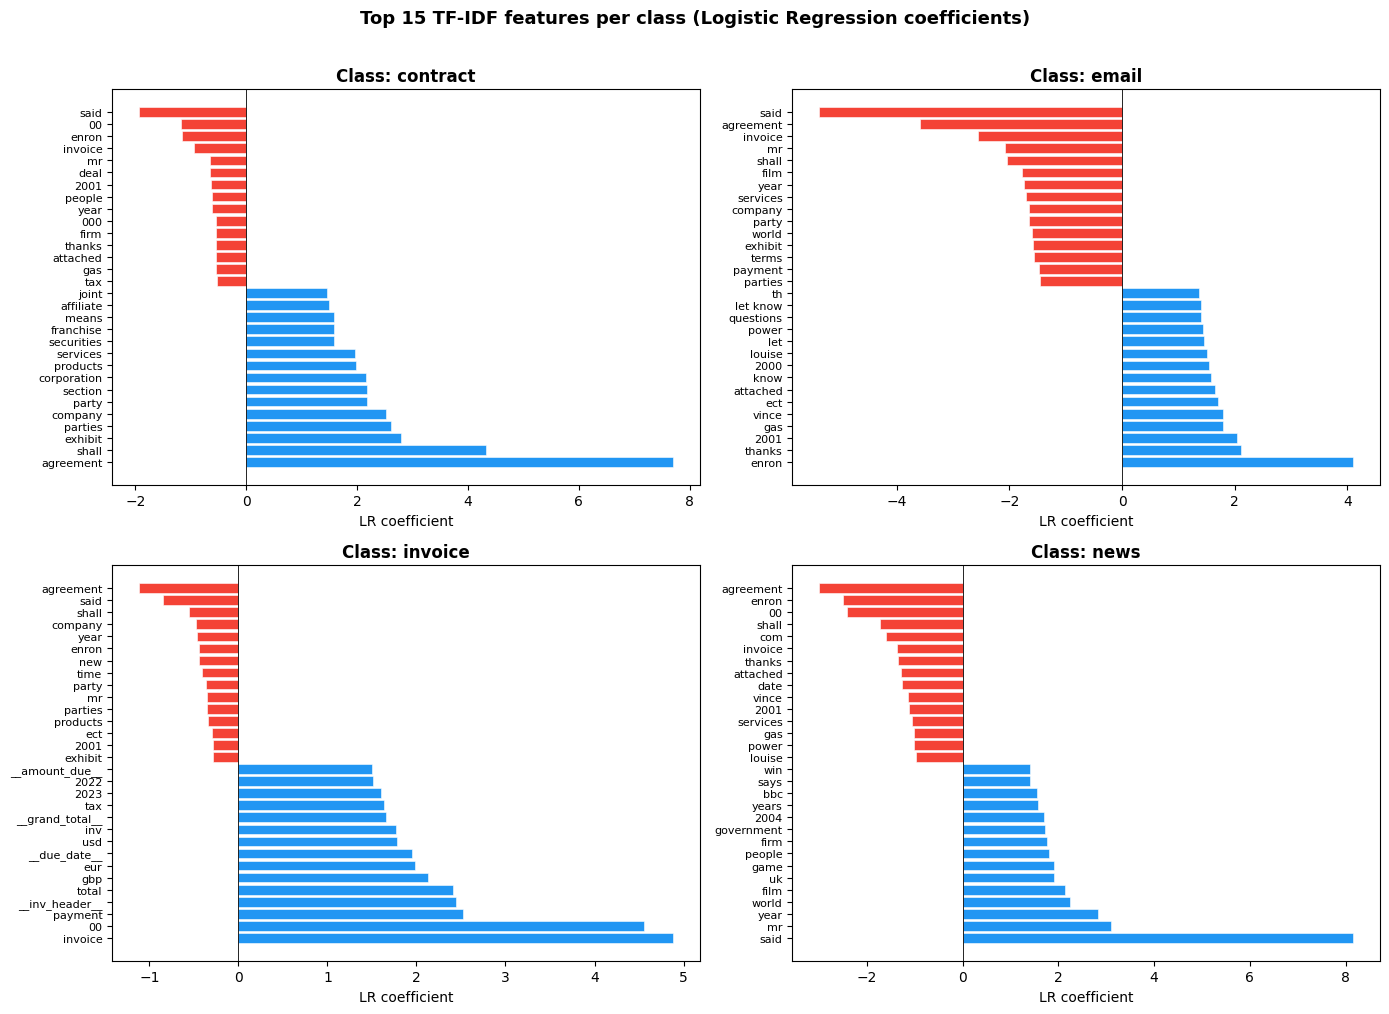

In [238]:
import matplotlib.pyplot as plt
import numpy as np

feature_names = np.array(tfidf.get_feature_names_out())
classes = lr_model.classes_
n_top = 15

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Top 15 TF-IDF features per class (Logistic Regression coefficients)',
             fontsize=13, fontweight='bold', y=1.01)

for ax, cls in zip(axes.ravel(), classes):
    cls_idx = list(classes).index(cls)
    coef = lr_model.coef_[cls_idx]
    top_pos = np.argsort(coef)[-n_top:][::-1]
    top_neg = np.argsort(coef)[:n_top]
    idx = np.concatenate([top_pos, top_neg[::-1]])
    values = coef[idx]
    labels = feature_names[idx]
    colors = ['#2196F3' if v >= 0 else '#F44336' for v in values]
    bars = ax.barh(range(len(labels)), values, color=colors, edgecolor='white', linewidth=0.4)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.axvline(0, color='black', linewidth=0.6)
    ax.set_title(f'Class: {cls}', fontweight='bold')
    ax.set_xlabel('LR coefficient')

plt.tight_layout()
plt.show()


## Learning Curve

Shows how macro-F1 changes with training set size. A large gap between
training and validation scores indicates overfitting; both curves plateauing
early suggests more data would help. Particularly relevant given the
small invoice class (~64 samples).


/Users/denis/Desktop/stats-final-project/Document-Classification-and-Information-Extraction-/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/denis/Desktop/stats-final-project/Document-Classification-and-Information-Extraction-/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/denis/Desktop/stats-final-project/Document-Classification-and-Information-Extraction-/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings

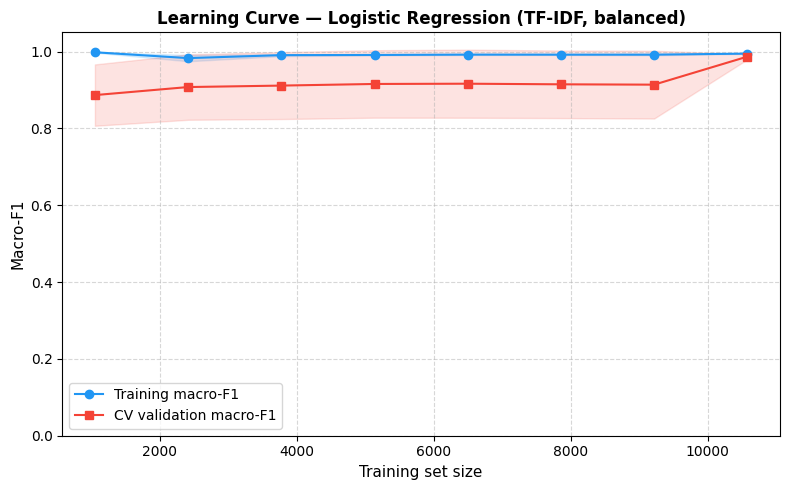


With 100% training data: train=0.9946, val=0.9868
With  10% training data: train=0.9981,  val=0.8866


In [239]:
from sklearn.model_selection import learning_curve
from sklearn.pipeline import Pipeline

lc_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True, stop_words='english',
        ngram_range=(1, 2), min_df=3, max_features=20000
    )),
    ('clf', LogisticRegression(
        max_iter=1000, random_state=42,
        class_weight='balanced', n_jobs=-1
    )),
])

train_sizes, train_scores, val_scores = learning_curve(
    lc_pipe, X_train, y_train,
    cv=5,
    scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1,
    random_state=42,
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_mean, 'o-', color='#2196F3', label='Training macro-F1')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#2196F3')
ax.plot(train_sizes, val_mean, 's-', color='#F44336', label='CV validation macro-F1')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#F44336')
ax.set_xlabel('Training set size', fontsize=11)
ax.set_ylabel('Macro-F1', fontsize=11)
ax.set_title('Learning Curve — Logistic Regression (TF-IDF, balanced)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f'\nWith 100% training data: train={train_mean[-1]:.4f}, val={val_mean[-1]:.4f}')
print(f'With  10% training data: train={train_mean[0]:.4f},  val={val_mean[0]:.4f}')


In [240]:
import sys
sys.path.insert(0, str(Path("..").resolve()))
from src.preprocessing import clean_for_classifier

def classify_document(text: str) -> dict:
    """Classify raw document text.

    Returns a dict with:
        label       — predicted class (news / email / contract / invoice)
        confidence  — probability for the predicted class (0-1)
        proba       — full class probability dict
    """
    cleaned = clean_for_classifier(text)
    X = tfidf.transform([cleaned])
    label = lr_model.predict(X)[0]
    proba = dict(zip(lr_model.classes_, lr_model.predict_proba(X)[0].round(3)))
    return {
        "label":      label,
        "confidence": round(float(proba[label]), 3),
        "proba":      proba,
    }

## Save model artifacts

Evaluate all 8 candidates (4 base + 2 tuned pipelines + XGBoost + SBERT) by test macro-F1, select the best, and persist the necessary files to `models/`.

A `model_type.txt` marker is written so `service.py` knows whether to use TF-IDF or SBERT for encoding at inference time.

In [241]:
import joblib
from pathlib import Path

models_dir = Path('../models')
models_dir.mkdir(exist_ok=True)

# ── Evaluate all candidates on the held-out test set ─────────────────────
y_pred_gs_lr  = gs_lr.predict(X_test)
y_pred_gs_svm = gs_svm.predict(X_test)

candidates = {
    'Naive Bayes':         ('tfidf', nb_model,   tfidf, y_test_pred_nb),
    'Linear SVM':          ('tfidf', svm_model,  tfidf, y_test_pred_svm),
    'Logistic Regression': ('tfidf', lr_model,   tfidf, y_test_pred_lr),
    'Random Forest':       ('tfidf', rf_model,   tfidf, y_test_pred_rf),
    'XGBoost':             ('tfidf', xgb_model,  tfidf, y_test_pred_xgb),
    'SBERT + LogReg':      ('sbert', sbert_lr,   None,  y_test_pred_sbert),
    'Tuned LR (GS)':       ('tfidf', gs_lr,      None,  y_pred_gs_lr),
    'Tuned SVM (GS)':      ('tfidf', gs_svm,     None,  y_pred_gs_svm),
}

scores = {
    name: f1_score(y_test, preds, average='macro')
    for name, (_, _, _, preds) in candidates.items()
}
print('Test macro-F1 per candidate:')
for name, score in sorted(scores.items(), key=lambda x: -x[1]):
    print(f'  {name:<28} {score:.4f}')

best_name = max(scores, key=scores.get)
infra, best_model, best_tfidf, _ = candidates[best_name]
print(f'\nSelected: {best_name} (test macro-F1 = {scores[best_name]:.4f})')

# ── Save ─────────────────────────────────────────────────────────────────
if infra == 'sbert':
    # SBERT + LogReg: save the fitted logistic regression and the encoder name.
    # service.py detects model_type='sbert' and uses SentenceTransformer to encode.
    joblib.dump(best_model, models_dir / 'lr_classifier.joblib')
    (models_dir / 'model_type.txt').write_text('sbert')
    (models_dir / 'sbert_model_name.txt').write_text(SBERT_MODEL_NAME)
    # Remove stale tfidf file so service.py doesn't accidentally load it
    tfidf_path = models_dir / 'tfidf_vectorizer.joblib'
    if tfidf_path.exists():
        tfidf_path.unlink()
    print('Saved: SBERT + LogReg')
    print(f'  Encoder : {SBERT_MODEL_NAME}')
elif best_tfidf is None:
    # GridSearch pipeline — unwrap components
    joblib.dump(best_model.best_estimator_.named_steps['tfidf'], models_dir / 'tfidf_vectorizer.joblib')
    joblib.dump(best_model.best_estimator_.named_steps['clf'],   models_dir / 'lr_classifier.joblib')
    (models_dir / 'model_type.txt').write_text('tfidf')
    print('Saved: tuned pipeline components (tfidf + clf)')
else:
    # Standalone TF-IDF model
    joblib.dump(best_tfidf,  models_dir / 'tfidf_vectorizer.joblib')
    joblib.dump(best_model,  models_dir / 'lr_classifier.joblib')
    (models_dir / 'model_type.txt').write_text('tfidf')
    print('Saved: standalone tfidf + classifier')

print(f'  {models_dir / "lr_classifier.joblib"}')
print(f'  {models_dir / "model_type.txt"} → {infra}')


Test macro-F1 per candidate:
  Linear SVM                   0.9961
  Tuned SVM (GS)               0.9961
  Random Forest                0.9947
  Tuned LR (GS)                0.9930
  Logistic Regression          0.9921
  XGBoost                      0.9915
  Naive Bayes                  0.9822
  SBERT + LogReg               0.9225

Selected: Linear SVM (test macro-F1 = 0.9961)
Saved: standalone tfidf + classifier
  ../models/lr_classifier.joblib
  ../models/model_type.txt → tfidf


## Save selectable models for the UI

Saves the three models offered in the frontend model selector into named subdirectories under `models/`. The auto-selected best model (cell above) is still the default. These three are chosen for their complementary strengths on unseen data:

| Key | Model | Why |
|---|---|---|
| `linear_svc` | Linear SVM | Highest test F1 on this dataset |
| `logistic_regression` | Logistic Regression | Calibrated probabilities, robust generalisation |
| `sbert_logreg` | SBERT + LogReg | Semantic embeddings, best on unseen vocabulary |

In [242]:
import joblib, shutil
from pathlib import Path

_mdir = Path('../models')
_mdir.mkdir(exist_ok=True)

# ── Linear SVM ──────────────────────────────────────────────────────────
_d = _mdir / 'linear_svc'
_d.mkdir(exist_ok=True)
joblib.dump(tfidf,     _d / 'tfidf.joblib')
joblib.dump(svm_model, _d / 'clf.joblib')
(_d / 'model_type.txt').write_text('tfidf')
print('Saved linear_svc')

# ── Logistic Regression ─────────────────────────────────────────────────
_d = _mdir / 'logistic_regression'
_d.mkdir(exist_ok=True)
joblib.dump(tfidf,    _d / 'tfidf.joblib')
joblib.dump(lr_model, _d / 'clf.joblib')
(_d / 'model_type.txt').write_text('tfidf')
print('Saved logistic_regression')

# ── SBERT + LogReg ──────────────────────────────────────────────────────
_d = _mdir / 'sbert_logreg'
_d.mkdir(exist_ok=True)
joblib.dump(sbert_lr,     _d / 'clf.joblib')
(_d / 'model_type.txt').write_text('sbert')
(_d / 'sbert_model_name.txt').write_text(SBERT_MODEL_NAME)
print('Saved sbert_logreg')

print()
print('All selectable models saved to models/<name>/')
for name in ['linear_svc', 'logistic_regression', 'sbert_logreg']:
    files = list((_mdir / name).iterdir())
    print(f'  {name}: {[f.name for f in files]}')


Saved linear_svc
Saved logistic_regression
Saved sbert_logreg

All selectable models saved to models/<name>/
  linear_svc: ['tfidf.joblib', 'clf.joblib', 'model_type.txt']
  logistic_regression: ['tfidf.joblib', 'clf.joblib', 'model_type.txt']
  sbert_logreg: ['clf.joblib', 'sbert_model_name.txt', 'model_type.txt']
